In [10]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
# Read the CSV file with a comma delimiter
df = pd.read_csv('/content/drive/MyDrive/praktikum_ml/praktikum12/data/Iris.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
from sklearn.preprocessing import StandardScaler

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Separating out the features
X = df.loc[:, features].values

# Separating out the target
y = df.loc[:, ['Species']].values

# Standardizing the features
X = StandardScaler().fit_transform(X)

df_standard = pd.DataFrame(X, columns=features)
df_standard.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


<Axes: >

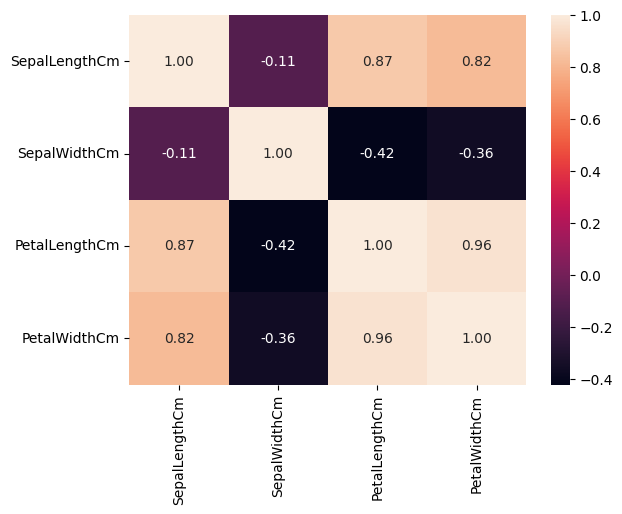

In [12]:
import seaborn as sns
sns.heatmap(df_standard.corr(), annot=True, fmt=".2f")

In [13]:
from sklearn.decomposition import PCA

# Applying PCA with 3 components
pca = PCA(n_components=3)
pca.fit(df_standard)
data_pca = pca.transform(df_standard)
data_pca = pd.DataFrame(data_pca, columns=['PC1', 'PC2', 'PC3'])
data_pca.head()

# Explained variance ratio
print(pca.explained_variance_ratio_)

[0.72770452 0.23030523 0.03683832]


<Axes: >

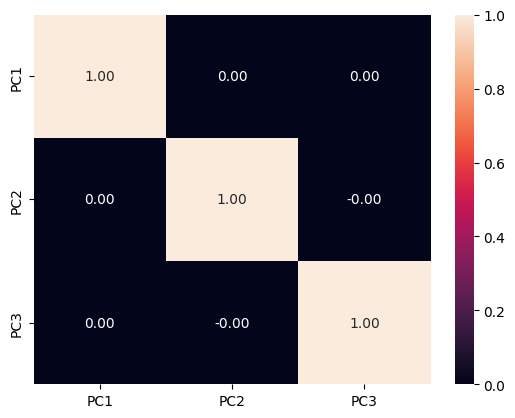

In [14]:
sns.heatmap(data_pca.corr(), annot=True, fmt=".2f")

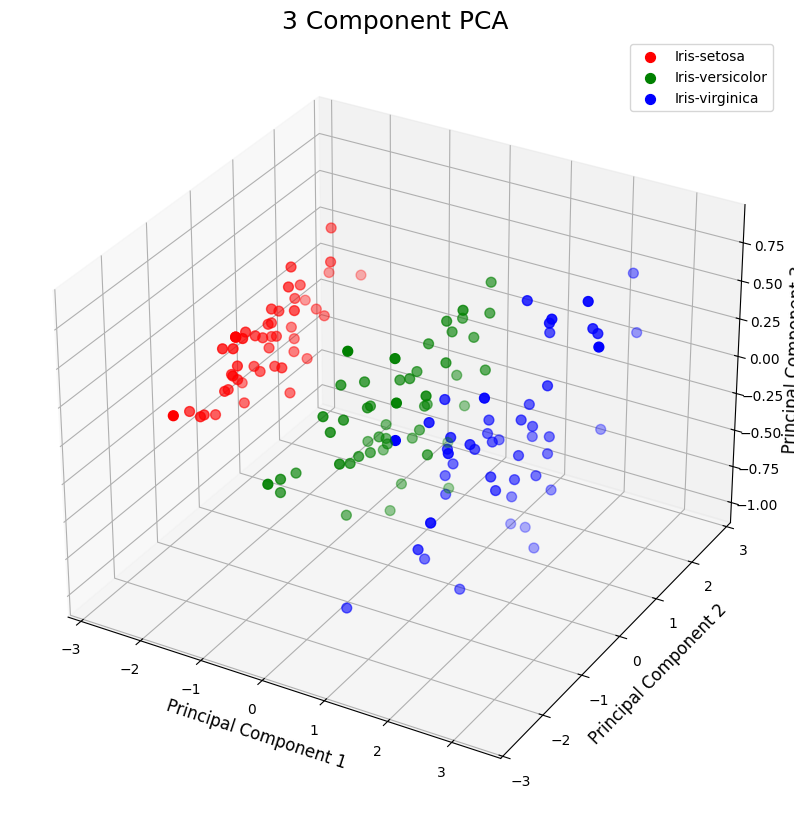

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Gabungkan dengan target
finalDf = pd.concat([data_pca, df[['Species']]], axis=1)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_zlabel('Principal Component 3', fontsize=12)
ax.set_title('3 Component PCA', fontsize=18)

targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']

for target, color in zip(targets, colors):
    indicesToKeep = finalDf['Species'] == target
    ax.scatter(
        finalDf.loc[indicesToKeep, 'PC1'],
        finalDf.loc[indicesToKeep, 'PC2'],
        finalDf.loc[indicesToKeep, 'PC3'],
        c=color,
        s=50,
        label=target
    )

ax.legend()
plt.show()

[0.72770452 0.23030523]


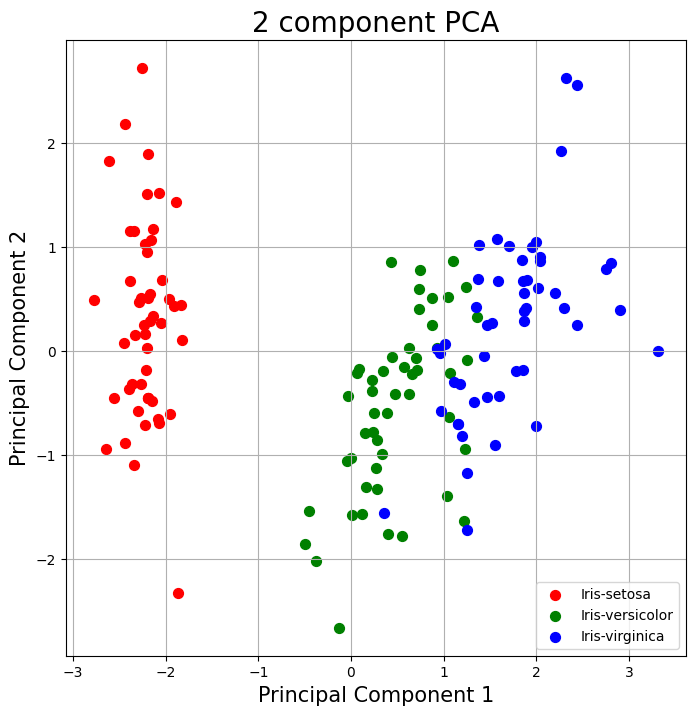

In [16]:
pca = PCA(n_components=2)
pca.fit(df_standard)
data_pca = pca.transform(df_standard)
data_pca = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])

finalDf = pd.concat([data_pca, df[['Species']]], axis=1)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('Principal Component 1', fontsize=15)
ax.set_ylabel('Principal Component 2', fontsize=15)
ax.set_title('2 component PCA', fontsize=20)

targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']

for target, color in zip(targets, colors):
    indicesToKeep = finalDf['Species'] == target
    ax.scatter(
        finalDf.loc[indicesToKeep, 'PC1'],
        finalDf.loc[indicesToKeep, 'PC2'],
        c=color,
        s=50
    )

ax.legend(targets)
ax.grid()
print(pca.explained_variance_ratio_)

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Load dataset Iris
df = pd.read_csv('/content/drive/MyDrive/praktikum_ml/praktikum12/data/Iris.csv')
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Separating out the features
X = df.loc[:, features].values
y = df.loc[:, ['Species']].values

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Standarisasi data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. PCA – ambil 2 komponen utama
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 5. SVM model (RBF kernel)
svm_model = SVC(kernel='rbf', gamma='scale')
svm_model.fit(X_train_pca, y_train)

# 6. Prediksi
y_pred = svm_model.predict(X_test_pca)

# 7. Akurasi
acc = accuracy_score(y_test, y_pred) * 100.0
print("Akurasi SVM dengan PCA:", acc, "%")

Akurasi SVM dengan PCA: 90.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
